<a href="https://colab.research.google.com/github/rumijay/Data-Science-2025/blob/main/Rumi_Unit7Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 7 Project: Polynomials, Splines, and GPs, Oh my!

**Task**:

Two parts:

1. Propose a data set that's compatible with pymc and/or bambi. I must approve your submission before you move on to part 2.

2. Create, analyze, and present any guassian process or approximate GP, degenerate or otherwise (this means glms and b splines are allowed), using pymc within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is), or if must be an actual GP
  - You must document and explain your model selection method. This means you must argue that your model choice (glm, b spline, GP) is better than at least one other choice. You may use either a theoretical or numerical argument.



Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a model or likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- Choose a data set with lots of columns, and lots of potential interactions between variables. It'll be more fun, and will make model/variable selection more relevant.

- This is not a competition to come up with the fanciest model structure. Find a data set that interests you, and apply the simplest model that captures the patterns in the data.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- I actually encourge you to use b splines; they work quite well, and trying to determine the location of the knots requires careful thought about the context of the data.

- Its ok to pick a data set for which you don't qute understand the context--so long as you think the context is cool.


**SORRY i havent finished. i wasnt here wednesday bcuz i felt sick and i went to the nurse friday class period bcuz of that.**

Data Set: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

In [13]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

!pip install bambi kagglehub

import bambi as bmb
import kagglehub

In [14]:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Dataset path:", path)

df = pd.read_csv(path + "/Housing.csv")

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Dataset path: /kaggle/input/housing-prices-dataset


In [15]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Part 1: Context / Introduction

In this project I am modeling **house prices** using different statistical models.

The goal is to understand how different features of a house influence its price.

Some possible predictors include:

- **area** (size of the house)
- **bedrooms**
- **bathrooms**
- **parking**

Housing prices are a good dataset for this project because relationships between variables may not always be linear. Larger homes generally cost more, but the relationship between area and price may curve or flatten.

Because of this, I will compare three model types:

1. **GLM (Generalized Linear Model)** – simple linear relationship
2. **B-Spline model** – allows flexible nonlinear relationships
3. **Gaussian Process (GP)** – models smooth nonlinear functions automatically

## Part 2: Data

This dataset contains information about houses and their selling prices.

Important columns include:

- **price** – target variable (house price)
- **area** – size of the house
- **bedrooms** – number of bedrooms
- **bathrooms** – number of bathrooms
- **parking** – number of parking spaces

These predictors were chosen because they are likely to influence house prices.

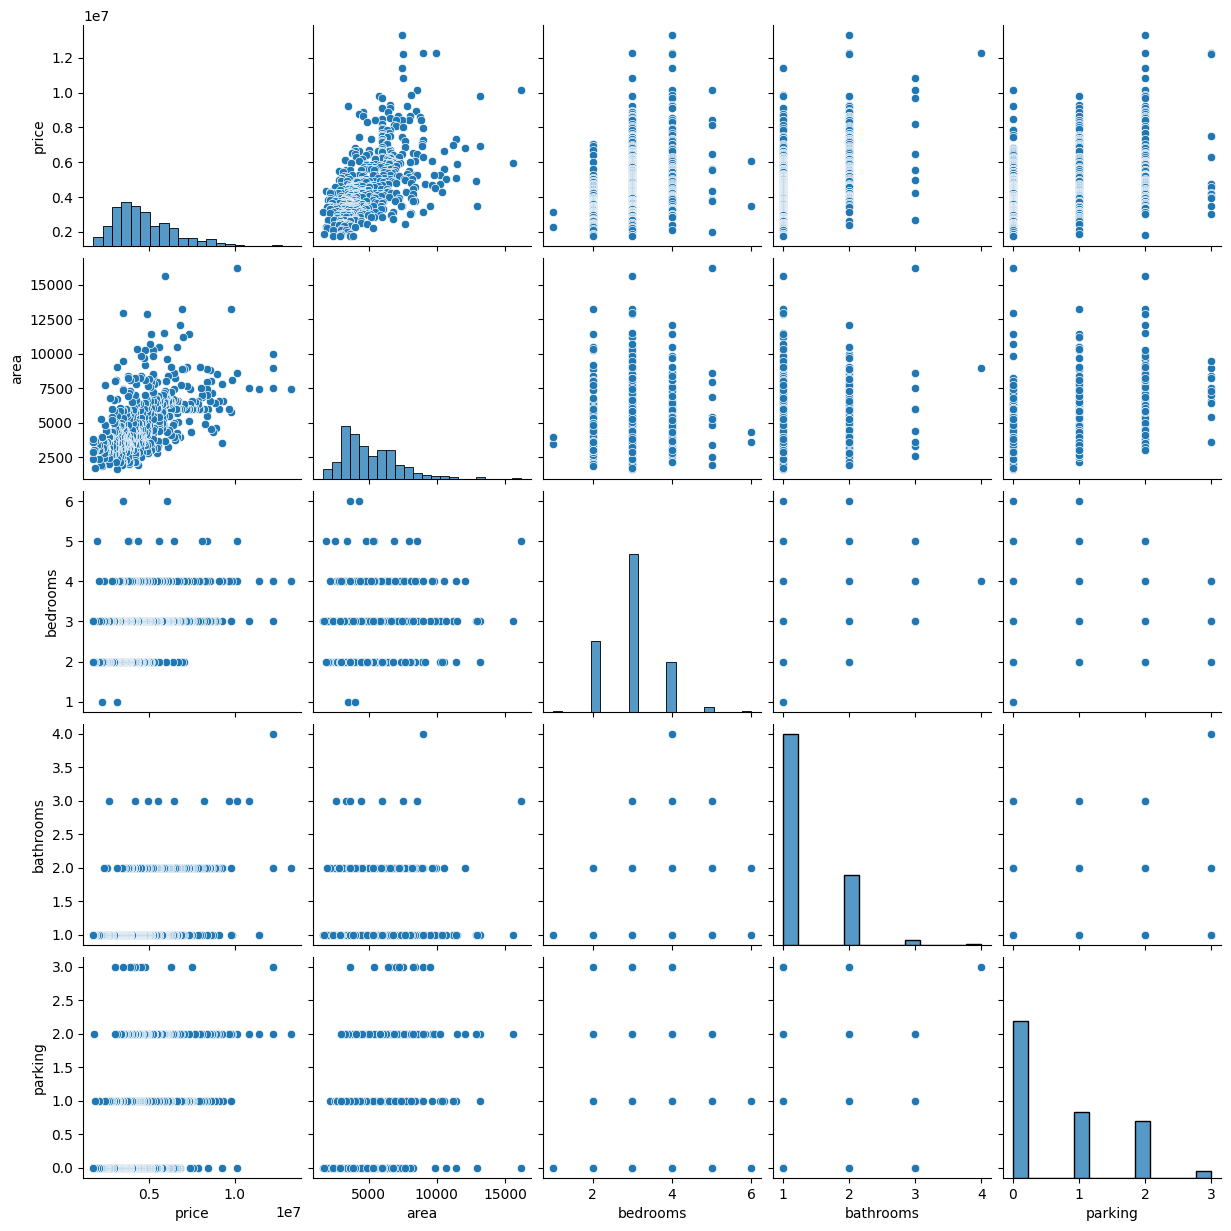

In [16]:

sns.pairplot(df[["price","area","bedrooms","bathrooms","parking"]])
plt.show()

The pairplot shows relationships between the variables.

Area appears to have a strong positive relationship with price.
Bedrooms and bathrooms also appear related to price, but less strongly.

Because the area vs price relationship may not be perfectly linear, more flexible models like splines or Gaussian processes may perform better than a simple linear model.

## Part 3: Building and Comparing Models

I will build three models:

Model 1 → GLM (baseline linear model)

Model 2 → B-Spline model (nonlinear relationship)

Model 3 → Gaussian Process model (flexible function)

Then I will compare them using model diagnostics such as WAIC.

In [ ]:
model_glm = bmb.Model(
    "price ~ area + bedrooms + bathrooms + parking",
    df
)

results_glm = model_glm.fit()

az.summary(results_glm)